## Dawn Andrei Pamesa
## TS31

Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

Loading the Dataset

In [2]:
df = pd.read_excel("Customer_Satisfaction.xlsx", sheet_name="Survey Responses")
df.head()

,id,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,1,5,6,4,7,4,6,6,4,4,4,4,4,3,NaN,NaN,1) Get the correlation of perception indicato...
1,6,3,5,6,6,6,5,7,4,7,4,6,5,5,NaN,NaN,and likelihood to recommend.
2,7,4,6,4,6,4,6,6,3,4,4,4,3,2,NaN,NaN,NaN
3,9,5,5,5,7,4,5,6,4,6,7,7,7,6,NaN,NaN,NaN
4,10,4,6,5,7,5,6,7,4,6,7,6,6,6,NaN,NaN,NaN


Selecting the Survey Columns

In [3]:
items = [f"x{i}" for i in range(12, 25)]
perceptions = items[:10]
outcomes = ["x22", "x23", "x24"]

names = {
    "x12": "Friendly employees", "x13": "Fun place to eat", "x14": "Large portions",
    "x15": "Fresh food", "x16": "Reasonable prices", "x17": "Attractive interior",
    "x18": "Excellent food taste", "x19": "Knowledgeable employees",
    "x20": "Proper food temperature", "x21": "Quick service",
    "x22": "Satisfaction", "x23": "Likely to return", "x24": "Likely to recommend",
}

df = df[["id"] + items]
df.head()

,id,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24
0,1,5,6,4,7,4,6,6,4,4,4,4,4,3
1,6,3,5,6,6,6,5,7,4,7,4,6,5,5
2,7,4,6,4,6,4,6,6,3,4,4,4,3,2
3,9,5,5,5,7,4,5,6,4,6,7,7,7,6
4,10,4,6,5,7,5,6,7,4,6,7,6,6,6


Check Missing Values

In [4]:
print(df.isnull().sum())
print("Duplicate ids:", df["id"].duplicated().sum())
print("Answers outside 1 to 7:", ((df[items] < 1) | (df[items] > 7)).sum().sum())
print("Respondents:", len(df))

id     0
x12    0
x13    0
x14    0
x15    0
x16    0
x17    0
x18    0
x19    0
x20    0
x21    0
x22    0
x23    0
x24    0
dtype: int64
Duplicate ids: 0
Answers outside 1 to 7: 0
Respondents: 405


Descriptive Statistics

In [5]:
desc = df[items].describe().T.round(2)
desc.insert(0, "item", desc.index.map(names))
desc

,item,count,mean,std,min,25%,50%,75%,max
x12,Friendly employees,405.0,3.64,1.21,1.0,2.0,4.0,5.0,5.0
x13,Fun place to eat,405.0,4.64,0.91,2.0,4.0,5.0,5.0,7.0
x14,Large portions,405.0,4.51,1.32,2.0,4.0,5.0,6.0,6.0
x15,Fresh food,405.0,5.76,1.20,4.0,5.0,6.0,7.0,7.0
x16,Reasonable prices,405.0,4.34,1.24,2.0,4.0,4.0,5.0,6.0
x17,Attractive interior,405.0,4.70,1.02,2.0,4.0,5.0,5.0,7.0
x18,Excellent food taste,405.0,5.31,1.08,3.0,5.0,5.0,6.0,7.0
x19,Knowledgeable employees,405.0,3.55,1.52,1.0,3.0,4.0,4.0,7.0
x20,Proper food temperature,405.0,4.52,1.17,2.0,4.0,5.0,5.0,7.0
x21,Quick service,405.0,5.21,2.04,1.0,3.0,7.0,7.0,7.0


## Part A: Correlation Analysis

Correlation Matrix

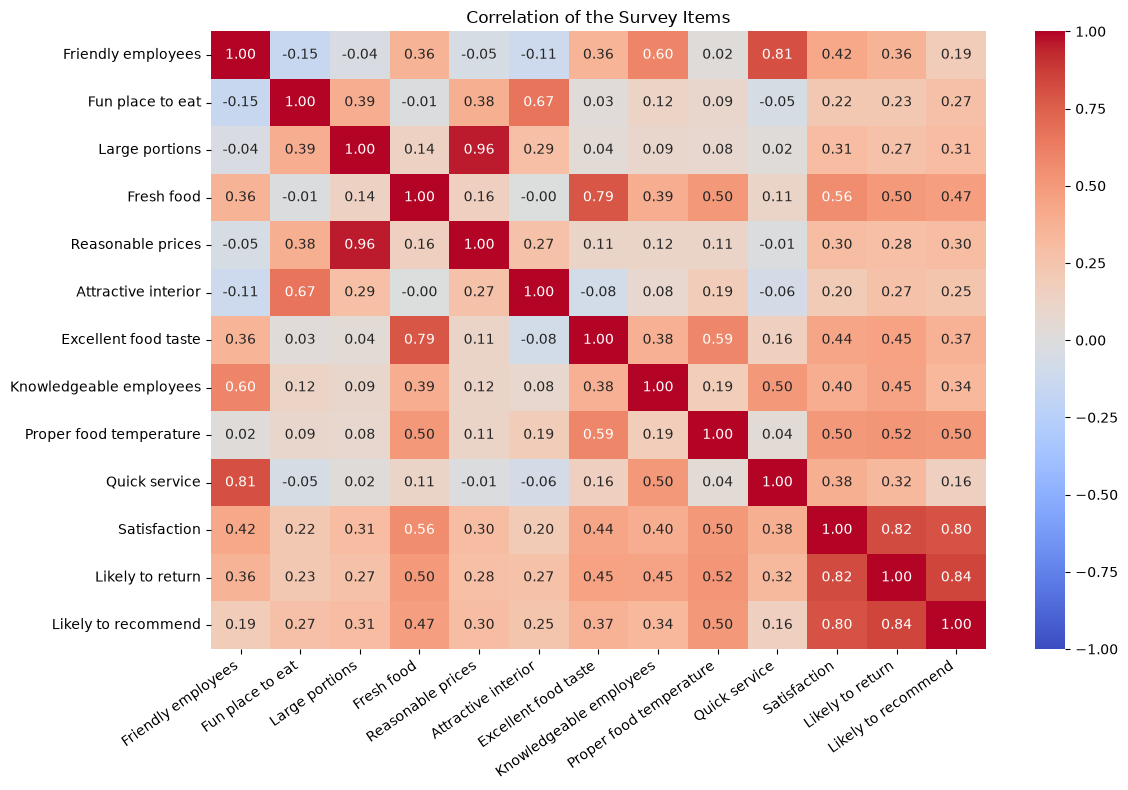

In [6]:
corr = df[items].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr.rename(index=names, columns=names), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of the Survey Items")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Correlation of Each Perception with the Outcomes

In [7]:
rows = []
for p in perceptions:
    for o in outcomes:
        r, p_value = stats.pearsonr(df[p], df[o])
        rows.append({"perception": names[p], "outcome": names[o], "r": round(r, 3), "p-value": p_value})

results = pd.DataFrame(rows)
results.pivot(index="perception", columns="outcome", values="r").sort_values("Satisfaction", ascending=False)

outcome,Likely to recommend,Likely to return,Satisfaction
perception,,,
Fresh food,0.471,0.496,0.559
Proper food temperature,0.505,0.517,0.504
Excellent food taste,0.372,0.454,0.440
Friendly employees,0.191,0.361,0.425
Knowledgeable employees,0.335,0.446,0.397
Quick service,0.163,0.324,0.384
Large portions,0.308,0.268,0.308
Reasonable prices,0.304,0.281,0.298
Fun place to eat,0.274,0.225,0.219


In [8]:
print("Significant at 0.05:", (results["p-value"] < 0.05).sum(), "out of", len(results))

satisfaction = results[results["outcome"] == "Satisfaction"].sort_values("r", ascending=False)
print("Strongest with satisfaction:", satisfaction.iloc[0]["perception"], satisfaction.iloc[0]["r"])
print("Weakest with satisfaction:", satisfaction.iloc[-1]["perception"], satisfaction.iloc[-1]["r"])
print("Fresh food vs food taste:", round(corr.loc["x15", "x18"], 3))

Significant at 0.05: 30 out of 30
Strongest with satisfaction: Fresh food 0.559
Weakest with satisfaction: Attractive interior 0.196
Fresh food vs food taste: 0.789


## Part B: One-Way ANOVA

Research Question and Hypotheses

Research question: Does customer satisfaction (x22) differ across the levels of perceived food freshness (x15)?

- H0: The mean satisfaction is the same for every freshness rating.
- H1: At least one freshness rating has a different mean satisfaction.

Variables: x15 (fresh food) is the independent variable, an ordinal 1 to 7 rating used as the groups. x22 (satisfaction) is the dependent variable, also an ordinal 1 to 7 rating, treated as numeric so the group means can be compared. Fresh food was chosen because it has the strongest correlation with satisfaction in Part A.

Choosing the Test

In [9]:
print(df["x15"].value_counts().sort_index())

x15
4     85
5     93
6     60
7    167
Name: count, dtype: int64


Nobody rated freshness below 4, so there are four groups (4, 5, 6 and 7). Since the satisfaction means of three or more groups are being compared, a one-way ANOVA is used. A t-test can only compare two groups at a time, and a Chi-square test is for two categorical variables, which would ignore that a satisfaction of 6 is higher than 5.

Checking the Assumptions

In [10]:
levels = [4, 5, 6, 7]
groups = [df[df["x15"] == level]["x22"] for level in levels]

df.groupby("x15")["x22"].agg(["count", "mean", "std"]).round(2)

,count,mean,std
x15,,,
4,85,3.99,0.59
5,93,4.35,0.78
6,60,4.85,1.29
7,167,5.51,0.99


In [11]:
for level, group in zip(levels, groups):
    stat, p_value = stats.shapiro(group)
    print(f"Shapiro-Wilk, freshness {level}: W = {stat:.3f}, p = {p_value:.2e}")

levene_stat, levene_p = stats.levene(*groups, center="mean")
print(f"\nLevene: F = {levene_stat:.2f}, p = {levene_p:.2e}")

Shapiro-Wilk, freshness 4: W = 0.580, p = 3.25e-14
Shapiro-Wilk, freshness 5: W = 0.814, p = 1.76e-09
Shapiro-Wilk, freshness 6: W = 0.903, p = 1.75e-04
Shapiro-Wilk, freshness 7: W = 0.856, p = 1.59e-11

Levene: F = 38.60, p = 6.23e-22


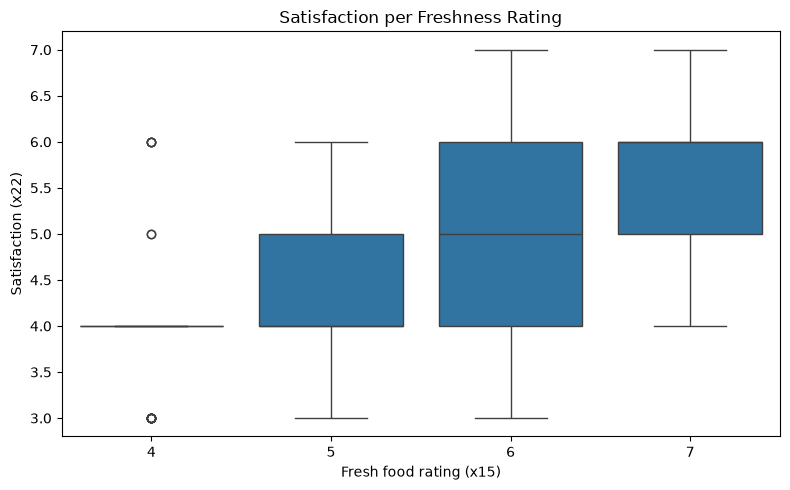

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="x15", y="x22", data=df)
plt.title("Satisfaction per Freshness Rating")
plt.xlabel("Fresh food rating (x15)")
plt.ylabel("Satisfaction (x22)")
plt.tight_layout()
plt.show()

Both normality (Shapiro-Wilk) and equal variances (Levene) are violated. However, every group has at least 60 respondents, so the ANOVA still holds up fairly well against non-normal data. Independence is met by design since each row is a different respondent. To be safe, Welch's ANOVA (does not assume equal variances) and Kruskal-Wallis (does not assume normality) are also run below.

Running the One-Way ANOVA

In [13]:
f_stat, p_value = stats.f_oneway(*groups)

grand_mean = df["x22"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_within = sum(((g - g.mean()) ** 2).sum() for g in groups)
df_between = len(groups) - 1
df_within = len(df) - len(groups)

f_manual = (ss_between / df_between) / (ss_within / df_within)
eta_squared = ss_between / (ss_between + ss_within)

print(f"F({df_between}, {df_within}) = {f_stat:.2f}, p = {p_value:.2e}")
print(f"F computed manually: {f_manual:.2f}")
print(f"Eta squared: {eta_squared:.3f}")

F(3, 401) = 61.72, p = 7.92e-33
F computed manually: 61.72
Eta squared: 0.316


Welch's ANOVA and Kruskal-Wallis

In [14]:
welch = stats.f_oneway(*groups, equal_var=False)
kruskal = stats.kruskal(*groups)

print(f"Welch's ANOVA: F = {welch.statistic:.2f}, p = {welch.pvalue:.2e}")
print(f"Kruskal-Wallis: H = {kruskal.statistic:.2f}, p = {kruskal.pvalue:.2e}")

Welch's ANOVA: F = 80.89, p = 5.83e-33
Kruskal-Wallis: H = 129.79, p = 6.01e-28


Post-Hoc Test (Tukey HSD)

In [15]:
tukey = stats.tukey_hsd(*groups)
print("Groups 0 to 3 are freshness ratings 4 to 7")
print(tukey)

Groups 0 to 3 are freshness ratings 4 to 7


Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.367     0.044    -0.726    -0.007
 (0 - 2)     -0.862     0.000    -1.266    -0.458
 (0 - 3)     -1.527     0.000    -1.846    -1.208
 (1 - 0)      0.367     0.044     0.007     0.726
 (1 - 2)     -0.495     0.008    -0.892    -0.099
 (1 - 3)     -1.160     0.000    -1.470    -0.850
 (2 - 0)      0.862     0.000     0.458     1.266
 (2 - 1)      0.495     0.008     0.099     0.892
 (2 - 3)     -0.665     0.000    -1.025    -0.304
 (3 - 0)      1.527     0.000     1.208     1.846
 (3 - 1)      1.160     0.000     0.850     1.470
 (3 - 2)      0.665     0.000     0.304     1.025



Plotting the Mean Satisfaction per Freshness Rating

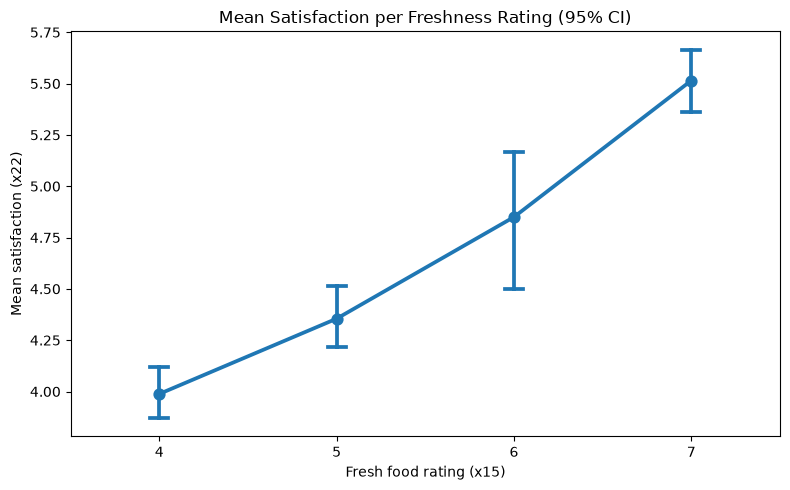

In [16]:
plt.figure(figsize=(8, 5))
sns.pointplot(x="x15", y="x22", data=df, errorbar=("ci", 95), capsize=0.1)
plt.title("Mean Satisfaction per Freshness Rating (95% CI)")
plt.xlabel("Fresh food rating (x15)")
plt.ylabel("Mean satisfaction (x22)")
plt.tight_layout()
plt.show()

Summary

In [17]:
means = df.groupby("x15")["x22"].mean()

print("\nSummary")
print("Strongest correlate of satisfaction: fresh food, r =", satisfaction.iloc[0]["r"])
print(f"ANOVA: F({df_between}, {df_within}) = {f_stat:.2f}, p = {p_value:.2e}")
print("Eta squared:", round(eta_squared, 3))
print("Mean satisfaction at freshness 4 and 7:", round(means[4], 2), "and", round(means[7], 2))
print("Decision at 0.05:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

print("\nThe mean satisfaction is different across the freshness ratings, and it goes up as freshness goes up.")
print("Welch's ANOVA and Kruskal-Wallis give the same decision, so the result holds even with the violated assumptions.")
print("Eta squared shows that freshness explains about a third of the variation in satisfaction, which is a large effect.")


Summary
Strongest correlate of satisfaction: fresh food, r = 0.559
ANOVA: F(3, 401) = 61.72, p = 7.92e-33
Eta squared: 0.316
Mean satisfaction at freshness 4 and 7: 3.99 and 5.51
Decision at 0.05: Reject H0

The mean satisfaction is different across the freshness ratings, and it goes up as freshness goes up.
Welch's ANOVA and Kruskal-Wallis give the same decision, so the result holds even with the violated assumptions.
Eta squared shows that freshness explains about a third of the variation in satisfaction, which is a large effect.


Bulleted Analysis

- Dataset: 405 respondents, 13 survey items on a 1 to 7 scale, with no missing values, no duplicate ids, and no answers outside 1 to 7.
- Part A: all 30 correlations between the ten perceptions and the three outcomes (satisfaction, return, recommend) are positive and significant at 0.05.
- Fresh food has the strongest correlation with satisfaction (r = 0.56), followed by proper food temperature (r = 0.50), while the attractive interior is the weakest (r = 0.20).
- Part B: the one-way ANOVA shows that mean satisfaction differs across the freshness ratings, F(3, 401) = 61.72, p < 0.001, so H0 is rejected.
- Mean satisfaction goes up at every level: 3.99, 4.35, 4.85 and 5.51 for freshness ratings 4 to 7.
- Tukey HSD: every pair of freshness ratings is significantly different (all p < 0.05), so satisfaction rises at each step and not just between the lowest and highest rating.
- Assumptions: normality and equal variances are both violated, but Welch's ANOVA (F = 80.89) and Kruskal-Wallis (H = 129.79) give the same decision.
- Practical importance: eta squared = 0.32, which is a large effect, and the 1.53-point gap between ratings 4 and 7 is more than one full step on the scale.
- Limitations: this is survey data, so it only shows association and not cause. Fresh food and food taste are strongly correlated (r = 0.79), and nobody rated freshness below 4.
- Next step: separate freshness from taste, for example by comparing satisfaction across the freshness ratings within customers who gave the same taste rating.

AI Use

The AI tool used is Claude Code (Claude Opus 5.5). It was used to write and run the Python code for the analysis and to draft the explanations, which were then rewritten and checked.

Prompts used:

1. Build the M2 Technical analysis with the code executed so every number comes from real output, together with a practice version and an instruction sheet so I can study each step. (paraphrased)
2. Answers to its follow-up questions: the dataset is Customer_Satisfaction.xlsx and I am doing the whole analysis for the group.
3. Rewrite the notebook in the same style as my previous Machine Learning notebook. (paraphrased)

Verification:

1. Every number in the report and the answers was taken from the output of the code above.
2. The F statistic from scipy was checked against a manual computation of the sums of squares, and they matched.
3. The same analysis was rebuilt separately in Excel with formulas, and the values matched the notebook.

Corrections:

1. scipy's Levene test uses the median by default, so it was set to center="mean" to use the classic Levene test.
2. The raw sheet has the instructor's task note in extra columns, so only the id and x12 to x24 were kept.
3. The first plan only had the standard ANOVA. After the assumption checks failed, Welch's ANOVA and Kruskal-Wallis were added.